## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


In [3]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [4]:
conn = sqlite3.connect('zippedData/im.db')

In [5]:
cur = conn.cursor()

In [6]:
df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

# **Data Understanding**
- For our analysis, the two most relevant data files we used are:
    - im.db, specifically the movie_basics and movie_ratings tables
    - bom.movie_gross.csv.gz 

In [7]:
# bom.movie_gross

In [8]:
df.shape

(3387, 5)

In [9]:
df.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [10]:
df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


- studio has missing data 
- domestic gross has missing data 
- foreign gross has missing data 
- foreign gross should be float not object 
- year data to be datetime 


In [12]:
df.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [13]:
# Missing values %
def missing(df,col):
    missing = (df[col].isna().sum()/len(df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [14]:
missing(df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [15]:
missing(df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [16]:
missing(df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives


In [17]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


### Movie Data ERD 
![alt text](movie_data_erd.jpeg)


In [18]:
# im.db movie_basics 
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [19]:
# im.db movie_ratings

query_2 = pd.read_sql("""
SELECT * FROM movie_ratings 
LIMIT 5;
""", conn)

query_2

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [20]:
# Your code here - remember to use markdown cells for comments as well!

possible Qs:
- does ratings affect box office success 
- which genre performs well financially - will need to feauture engineer a primary genre column 
- Which studios are most successful, and does that align with the top-performing genres? 
- Out of the films that has a foreign relase, which genre was most successfull amongst international viewers





**Business question analysis:**

**1. Which genres deliver the best financial return, measured by ROI and median profit?**

In [ ]:
# 1. We load in our movie budget data from the im.db database and check the first 5 rows of the data.

budgets_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
budgets_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


---


In [ ]:
# 2. Then we check the data to know how to clean it up. We check the info, missing values and duplicates.

print("Dataset Information")
budgets_df.info()

print("\nMissing Values")
print(budgets_df.isna().sum())

print("\nDuplicate Rows")
print(budgets_df.duplicated().sum())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB

Missing Values
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

Duplicate Rows
0


In [ ]:
# 3.Since the money columns are in float format, we can go ahead and calculate the profit column by subtracting the production_budget from the worldwide_gross. We will create a new column called profit to store the results of this calculation.

budgets_df["profit"] = budgets_df["worldwide_gross"] - budgets_df["production_budget"]

#We then calculate the ROI (Return on Investment) by dividing the profit by the production_budget and multiplying by 100 to get a percentage. We will create a new column called ROI to store the results of this calculation.
budgets_df["ROI"] = (budgets_df["profit"] / budgets_df["production_budget"]) * 100

#Then view the results of the calculations by checking the first 5 rows of the data.
budgets_df[["movie","production_budget", "worldwide_gross", "profit", "ROI"]].head()

,movie,production_budget,worldwide_gross,profit,ROI
0,Avatar,425000000.0,2.776345e+09,2.351345e+09,553.257713
1,Pirates of the Caribbean: On Stranger Tides,410600000.0,1.045664e+09,6.350639e+08,154.667286
2,Dark Phoenix,350000000.0,1.497624e+08,-2.002376e+08,-57.210757
3,Avengers: Age of Ultron,330600000.0,1.403014e+09,1.072414e+09,324.384139
4,Star Wars Ep. VIII: The Last Jedi,317000000.0,1.316722e+09,9.997217e+08,315.369636


In [ ]:
# 4. Next we get the genres from the IMDb database
conn = sqlite3.connect('zippedData/im.db')

movie_basics = pd.read_sql("""
SELECT
    primary_title, start_year, genres
FROM movie_basics
WHERE genres IS NOT NULL
""", conn)

movie_basics.head()

,primary_title,start_year,genres
0,Sunghursh,2013,"Action,Crime,Drama"
1,One Day Before the Rainy Season,2019,"Biography,Drama"
2,The Other Side of the Wind,2018,Drama
3,Sabse Bada Sukh,2018,"Comedy,Drama"
4,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy"


In [ ]:
#5. We should then create a release year in the budget data inorder to match the movies more accurately
budgets_df["release_year"] = pd.to_datetime(budgets_df["release_date"]).dt.year

# 6. Now I merge the datasets using an inner join on the movie title and release year. This will give us a combined dataset with both financial and genre information for each movie.
movies_df = budgets_df.merge(
    movie_basics,left_on=["movie","release_year"],right_on=["primary_title","start_year"],how="inner"
)

movies_df.shape
movies_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,ROI,release_year,primary_title,start_year,genres
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy"
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi"
2,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,324.384139,2015,Avengers: Age of Ultron,2015,"Action,Adventure,Sci-Fi"
3,7,2018-04-27,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,1.748134e+09,582.711400,2018,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi"
4,9,2017-11-17,Justice League,300000000.0,229024295.0,6.559452e+08,3.559452e+08,118.648403,2017,Justice League,2017,"Action,Adventure,Fantasy"


In [ ]:
#7. Now we could explode the genres column to create a new row for each genre associated with a movie. This will allow us to analyze the data by genre more easily.
genre_df = movies_df.copy()

genre_df["genre"] = genre_df["genres"].str.split(",")

genre_df = genre_df.explode("genre")

genre_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,ROI,release_year,primary_title,start_year,genres,genre
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Action
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Adventure
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Fantasy
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-200237650.0,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi",Action
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-200237650.0,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi",Adventure


In [ ]:
#8. Now we can calculate the financial performance by genre by grouping the data by genre and calculating the mean of the profit and ROI columns.
genre_performance = (
    genre_df
    .groupby("genre")
    .agg(
        median_ROI=("ROI", "median"),
        median_profit=("profit", "median"),
        movie_count=("movie", "count")
    )
    .sort_values("median_ROI", ascending=False)
)

genre_performance.style.format({
    "median_ROI": "{:,.2f}%",
    "median_profit": "${:,.2f}",
    "movie_count": "{:,}"
})

,median_ROI,median_profit,movie_count
genre,,,
Mystery,207.57%,"$32,054,270.00",128
Animation,198.19%,"$194,139,928.50",102
Sci-Fi,167.27%,"$116,238,899.50",134
Adventure,161.93%,"$128,050,874.00",353
Horror,138.33%,"$14,720,203.00",187
Comedy,133.22%,"$29,119,358.00",519
Romance,129.95%,"$15,925,971.00",189
Music,128.64%,"$12,499,242.00",51
Thriller,125.84%,"$26,294,152.00",268


In [ ]:
# We should filter genres with very small sample sizes before making recommendations. Otherwise, a genre could appear to have spectacular ROI based on only one or two movies.
# A minimum of 20 movies is a good threshold to use for filtering. We can filter the genre_performance dataframe to only include genres with at least 20 movies.
filtered_genres = genre_performance[genre_performance["movie_count"] >= 20]


filtered_genres.style.format({
    "median_ROI": "{:,.2f}%",
    "median_profit": "${:,.2f}",
    "movie_count": "{:,}"
})


,median_ROI,median_profit,movie_count
genre,,,
Mystery,207.57%,"$32,054,270.00",128
Animation,198.19%,"$194,139,928.50",102
Sci-Fi,167.27%,"$116,238,899.50",134
Adventure,161.93%,"$128,050,874.00",353
Horror,138.33%,"$14,720,203.00",187
Comedy,133.22%,"$29,119,358.00",519
Romance,129.95%,"$15,925,971.00",189
Music,128.64%,"$12,499,242.00",51
Thriller,125.84%,"$26,294,152.00",268


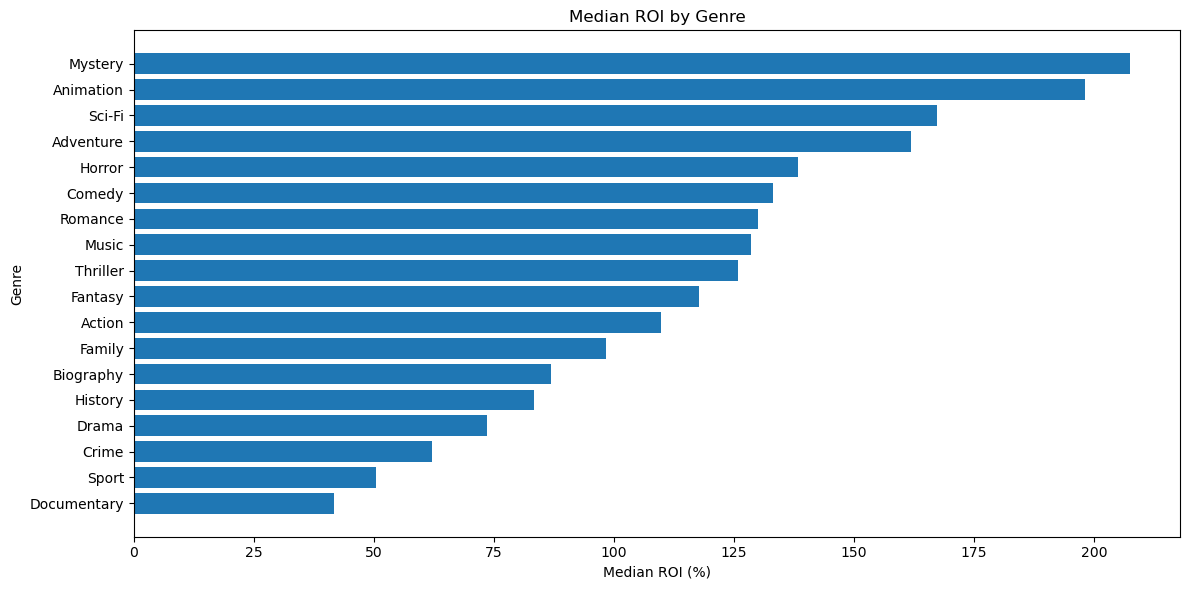

In [ ]:
#9. Visualize the results using a bar chart.
# First we visualize the median ROI by genre
ROI_plot = filtered_genres.sort_values("median_ROI")
plt.figure(figsize=(12,6))

plt.barh(ROI_plot.index, ROI_plot["median_ROI"])
plt.xlabel("Median ROI (%)")
plt.ylabel("Genre")
plt.title("Median ROI by Genre")

plt.tight_layout()
plt.show()

**Prioritize Animation, Adventure and Sci-Fi**

These three genres perform strongly on both profitability and ROI:

Animation – highest median profit ($194M) and very high ROI (198%).

Adventure – second-highest median profit ($128M) and strong ROI (162%).

Sci-Fi – third-highest median profit ($116M) and ROI (168%).

Recommendation: These should be the primary genres for investment because they combine strong returns with high absolute profits.

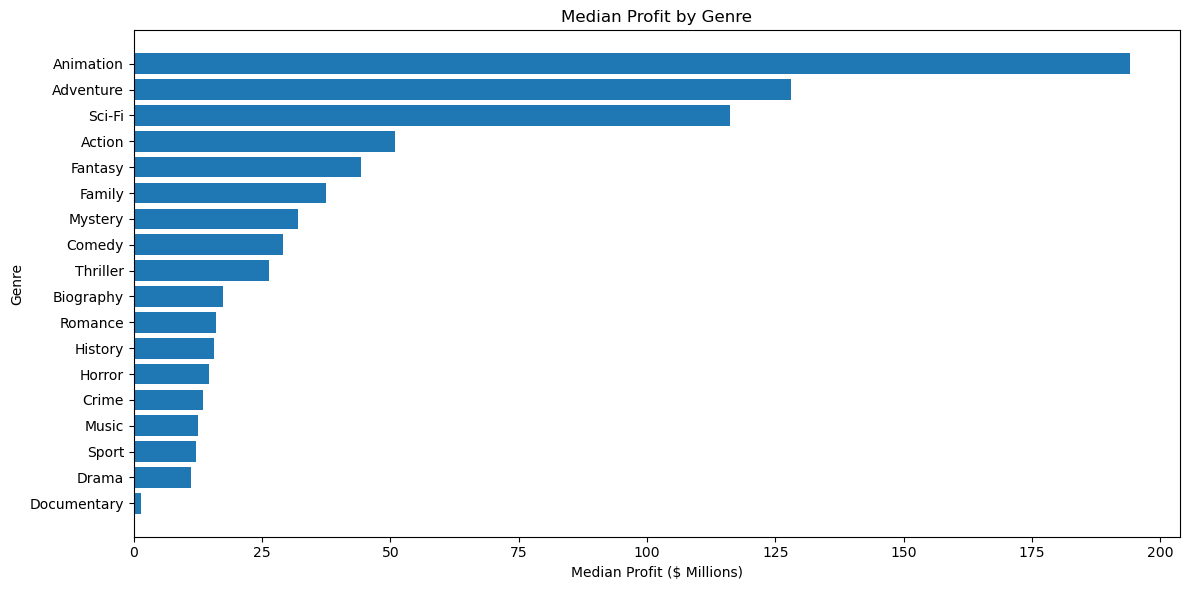

In [ ]:
# Visualize the median profit by genre
profit_plot = filtered_genres.sort_values("median_profit")

profit_plot["median_profit_millions"] = (
    profit_plot["median_profit"] / 1_000_000
)

profit_plot = profit_plot.sort_values("median_profit_millions")
plt.figure(figsize=(12,6))

plt.barh(profit_plot.index, profit_plot["median_profit_millions"])
plt.xlabel("Median Profit ($ Millions)")
plt.ylabel("Genre")
plt.title("Median Profit by Genre")

plt.tight_layout()
plt.show()

**Based on the visualizations, the following are the best recommendations;**

**1. Prioritize Animation, Adventure and Sci-Fi**

These three genres perform strongly on both profitability and ROI:

Animation – highest median profit ($194M) and very high ROI (198%).

Adventure – second-highest median profit ($128M) and strong ROI (162%).

Sci-Fi – third-highest median profit ($116M) and ROI (168%).

Recommendation: These should be the primary genres for investment because they combine strong returns with high absolute profits.

**2. Consider Mystery for high-return, lower-risk investments**

Mystery has the highest median ROI (~208%), meaning it generates the strongest return relative to the amount invested. However, its median profit (~$32M) is much lower than Animation, Adventure and Sci-Fi.

Recommendation: Invest in Mystery when the goal is capital efficiency/ROI, rather than maximizing total dollar profit.

**3. Be very careful when investing in Drama, Sport and Documentary**

These genres appear at the bottom of the profitability chart:

Documentary – extremely low median profit and ROI.

Drama – low median profit and relatively low ROI.

Sport – low median profit and ROI.

Recommendation: Avoid large investments in these genres unless there are specific factors such as a strong franchise, famous cast, low production budget, or clear target audience that justify the investment.

**EDA Summary**


**1. I first examined the structure of the dataset**

Checked the columns, data types, number of records, and missing values.
Identified the important variables for analyzing movie performance, such as genre, budget, revenue, profit, ROI, and movie count.

**2. I analyzed movie profitability**

Calculated profit to determine how much money movies made after accounting for their budget.
I also calculated ROI (Return on Investment) to measure how efficiently the budget was converted into revenue/profit.

**3. I grouped movies by genre**

I used groupby("genre") to compare genres.

**4. I calculated:**

Median ROI
Median profit
Movie count
I used the median because movie profits and ROI can be heavily affected by a few extremely successful blockbuster movies. Median gives us a better picture of the typical movie in each genre.

**5. I visualized genre performance**

I created charts comparing median profit by genre. The visualization helped us see which genres generally perform better financially.


**Recommendation**

The studio should prioritize genres that consistently demonstrate strong median profit and ROI, while considering the number of movies available for each genre. Investment decisions should be based on both profitability and efficiency rather than revenue alone, with lower-performing genres receiving more cautious or smaller-budget investments.